## **Lexical Bridge Photo Mission - Data EDA**

### **Purpose**

The purpose of this notebook is to explore the image dataset prepared for the Lexical Bridge Photo Mission feature. The dataset contains 9 image classes, which are mapped into 3 broader categories (Animal, Nature, and Daily_Life). These categories are used to support the photo challenge activity, where children are asked to provide an image related to a selected theme.

This notebook performs exploratory data analysis before CNN training. It checks the dataset structure, class and category distribution, image dimensions, RGB channel means, brightness levels, and representative image samples. These analyses help confirm whether the dataset is suitable for training and guide preprocessing decisions such as resizing, augmentation, and normalization.


### **Structure**
This notebook is organized into the following sections

1. Mount Google Drive and extract the dataset ZIP file
2. Configure dataset paths and class mappings
3. Collect image metadata and basic image statistics
4. Analyze class and category distributions
5. Analyze image size distribution
6. Analyze RGB channel means and brightness distribution
7. Visualize four sample images from each class
8. Generate a final dataset summary report

## 1. Mount Google Drive and extract the dataset ZIP file

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.unpack_archive(
    '/content/drive/MyDrive/dyslexiread_dataset.zip',
    '/content/dataset'
)

Mounted at /content/drive


In [8]:
import shutil
from pathlib import Path

DATASET_DIR = Path('/content/dataset')
ZIP_PATH = '/content/drive/MyDrive/dyslexiread_dataset.zip'

shutil.unpack_archive(ZIP_PATH, str(DATASET_DIR))
print('Unpack Done')

!ls /content/dataset
!ls /content/dataset/train

Unpack Done
test  train  val
bicycle  bird  car  cat  dog  flower  fruit  shoe  vegetable


## 2. Configure dataset paths and class mappings

In [9]:
import os
import random
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Map original image class names into broader project categories
CATEGORY_MAP = {
    'cat': 'animal',     'dog': 'animal',     'bird': 'animal',
    'flower': 'nature',  'fruit': 'nature',   'vegetable': 'nature',
    'car': 'daily_life', 'bicycle': 'daily_life', 'shoe': 'daily_life',
}

# Define the color used for each broader category in visualizations
CATEGORY_COLORS = {
    'animal':     '#FF6B6B',
    'nature':     '#51CF66',
    'daily_life': '#339AF0',
}
SPLITS = ['train', 'val', 'test']

## 3. Collect image metadata and basic image statistics

In [10]:
rows = []
# Loop through each dataset split and class folder
for split in SPLITS:
    for cls in CATEGORY_MAP:
        cls_dir = DATASET_DIR / split / cls
        files_list = list(cls_dir.glob('*.jpg'))

        # Read each image and extract basic metadata / statistics
        for f in tqdm(files_list, desc=f'{split}/{cls}', leave=False):
            try:
                with Image.open(f) as img:
                    w, h = img.size
                    arr = np.array(img.convert('RGB'))

                rows.append({
                    'path':     str(f),
                    'split':    split,
                    'class':    cls,
                    'category': CATEGORY_MAP[cls],
                    'width':    w,
                    'height':   h,
                    'aspect':   w / h,
                    'pixels':   w * h,
                    'r_mean':   arr[:, :, 0].mean(),
                    'g_mean':   arr[:, :, 1].mean(),
                    'b_mean':   arr[:, :, 2].mean(),
                    'brightness': arr.mean(),
                    'file_kb':  f.stat().st_size / 1024,
                })

            # Skip unreadable images and show the error
            except Exception as e:
                print(f'Error: {f} → {e}')

df = pd.DataFrame(rows)
print(f'Total: {len(df)} images')
df.head()

Total: 8885 images


,path,split,class,category,width,height,aspect,pixels,r_mean,g_mean,b_mean,brightness,file_kb
0,/content/dataset/train/cat/cat_0658.jpg,train,cat,animal,675,683,0.988287,461025,97.874517,96.511827,93.000265,95.795536,92.510742
1,/content/dataset/train/cat/cat_0083.jpg,train,cat,animal,921,297,3.101010,273537,95.661625,93.109068,90.729185,93.166626,48.313477
2,/content/dataset/train/cat/cat_0631.jpg,train,cat,animal,266,460,0.578261,122360,107.890536,90.256407,68.525629,88.890858,30.712891
3,/content/dataset/train/cat/cat_0871.jpg,train,cat,animal,827,545,1.517431,450715,164.520258,157.503141,142.258336,154.760578,85.273438
4,/content/dataset/train/cat/cat_0939.jpg,train,cat,animal,280,426,0.657277,119280,34.166206,33.089428,37.811745,35.022460,30.402344


## 4. Analyze class and category distributions

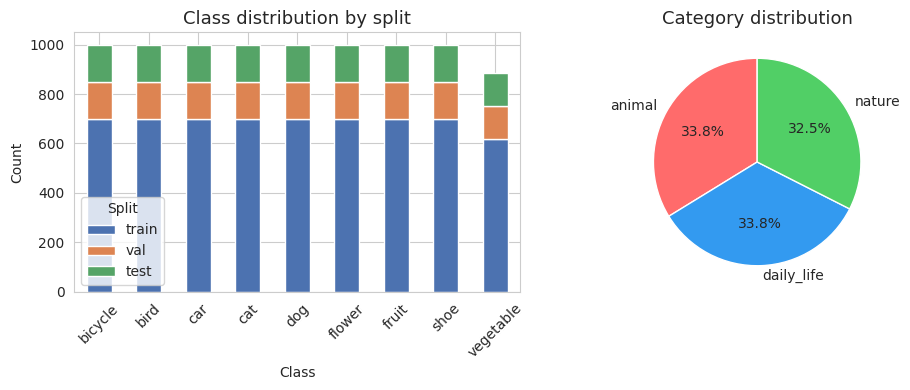

Class counts
split      train  val  test
class                      
bicycle      700  150   150
bird         700  150   150
car          700  150   150
cat          700  150   150
dog          700  150   150
flower       700  150   150
fruit        700  150   150
shoe         700  150   150
vegetable    619  133   133

Total: 8885


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count images for each class across train, validation, and test splits
split_counts = df.groupby(['class', 'split']).size().unstack(fill_value=0)
split_counts = split_counts[['train', 'val', 'test']]
# Plot stacked bar chart for class distribution by split
split_counts.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#4C72B0', '#DD8452', '#55A467']
)
axes[0].set_title('Class distribution by split', fontsize=13)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Split')

# Count images for each broader category
cat_counts = df['category'].value_counts()

# Plot pie chart for category-level distribution
axes[1].pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    colors=[CATEGORY_COLORS[c] for c in cat_counts.index],
    startangle=90
)
axes[1].set_title('Category distribution', fontsize=13)
plt.tight_layout()
plt.show()
print('Class counts')
print(split_counts)
print(f'\nTotal: {len(df)}')

## 5. Analyze image size distribution

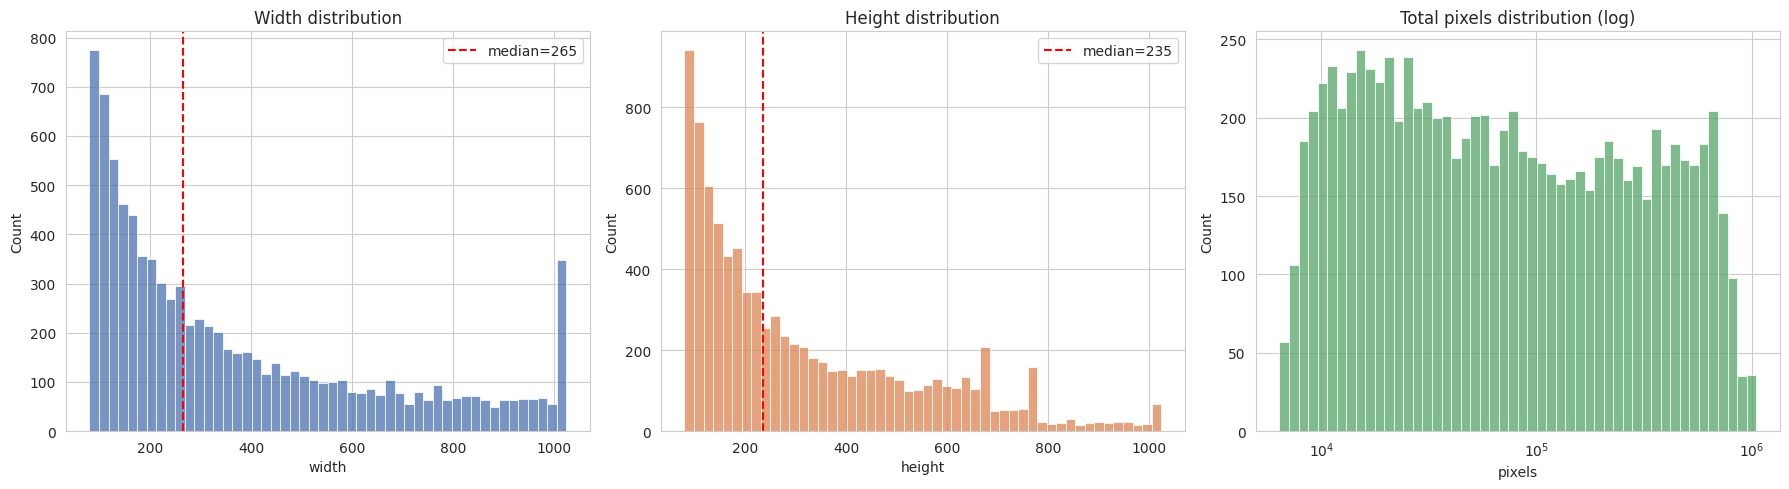

Size statistics
         width   height   aspect  file_kb
count  8885.00  8885.00  8885.00  8885.00
mean    369.23   315.18     1.26    60.03
std     277.06   223.24     0.67    76.11
min      80.00    80.00     0.13     1.85
25%     145.00   133.00     0.85     9.69
50%     265.00   235.00     1.12    25.72
75%     531.00   453.00     1.50    82.46
max    1024.00  1024.00     9.56   606.35


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot width distribution and mark the median width
sns.histplot(df['width'], bins=50, ax=axes[0], color='#4C72B0')
axes[0].axvline(df['width'].median(), color='red', linestyle='--', label=f'median={df["width"].median():.0f}')
axes[0].set_title('Width distribution')
axes[0].legend()

# Plot height distribution and mark the median height
sns.histplot(df['height'], bins=50, ax=axes[1], color='#DD8452')
axes[1].axvline(df['height'].median(), color='red', linestyle='--', label=f'median={df["height"].median():.0f}')
axes[1].set_title('Height distribution')
axes[1].legend()

# Plot total pixel count distribution using a log scale
sns.histplot(df['pixels'], bins=50, ax=axes[2], color='#55A467', log_scale=True)
axes[2].set_title('Total pixels distribution (log)')
plt.tight_layout()
plt.show()
print('Size statistics')
print(df[['width', 'height', 'aspect', 'file_kb']].describe().round(2))

## 6. Analyze RGB channel means and brightness distribution

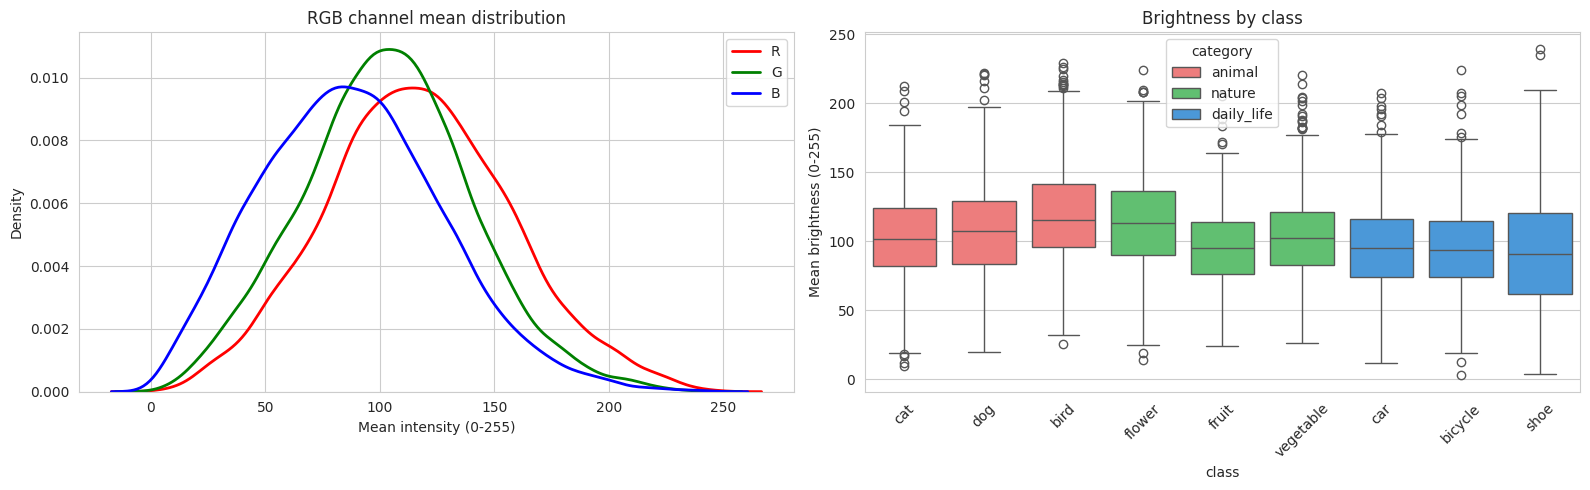

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot the distribution of average RGB channel values
for color, channel in zip(['red', 'green', 'blue'], ['r_mean', 'g_mean', 'b_mean']):
    sns.kdeplot(df[channel], ax=axes[0], color=color, label=channel.split('_')[0].upper(), linewidth=2)
axes[0].set_title('RGB channel mean distribution')
axes[0].set_xlabel('Mean intensity (0-255)')
axes[0].legend()

# Compare average image brightness across classes
sns.boxplot(data=df, x='class', y='brightness', ax=axes[1], hue='category',
            palette=CATEGORY_COLORS, dodge=False)
axes[1].set_title('Brightness by class')
axes[1].set_ylabel('Mean brightness (0-255)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Visualize four sample images from each class

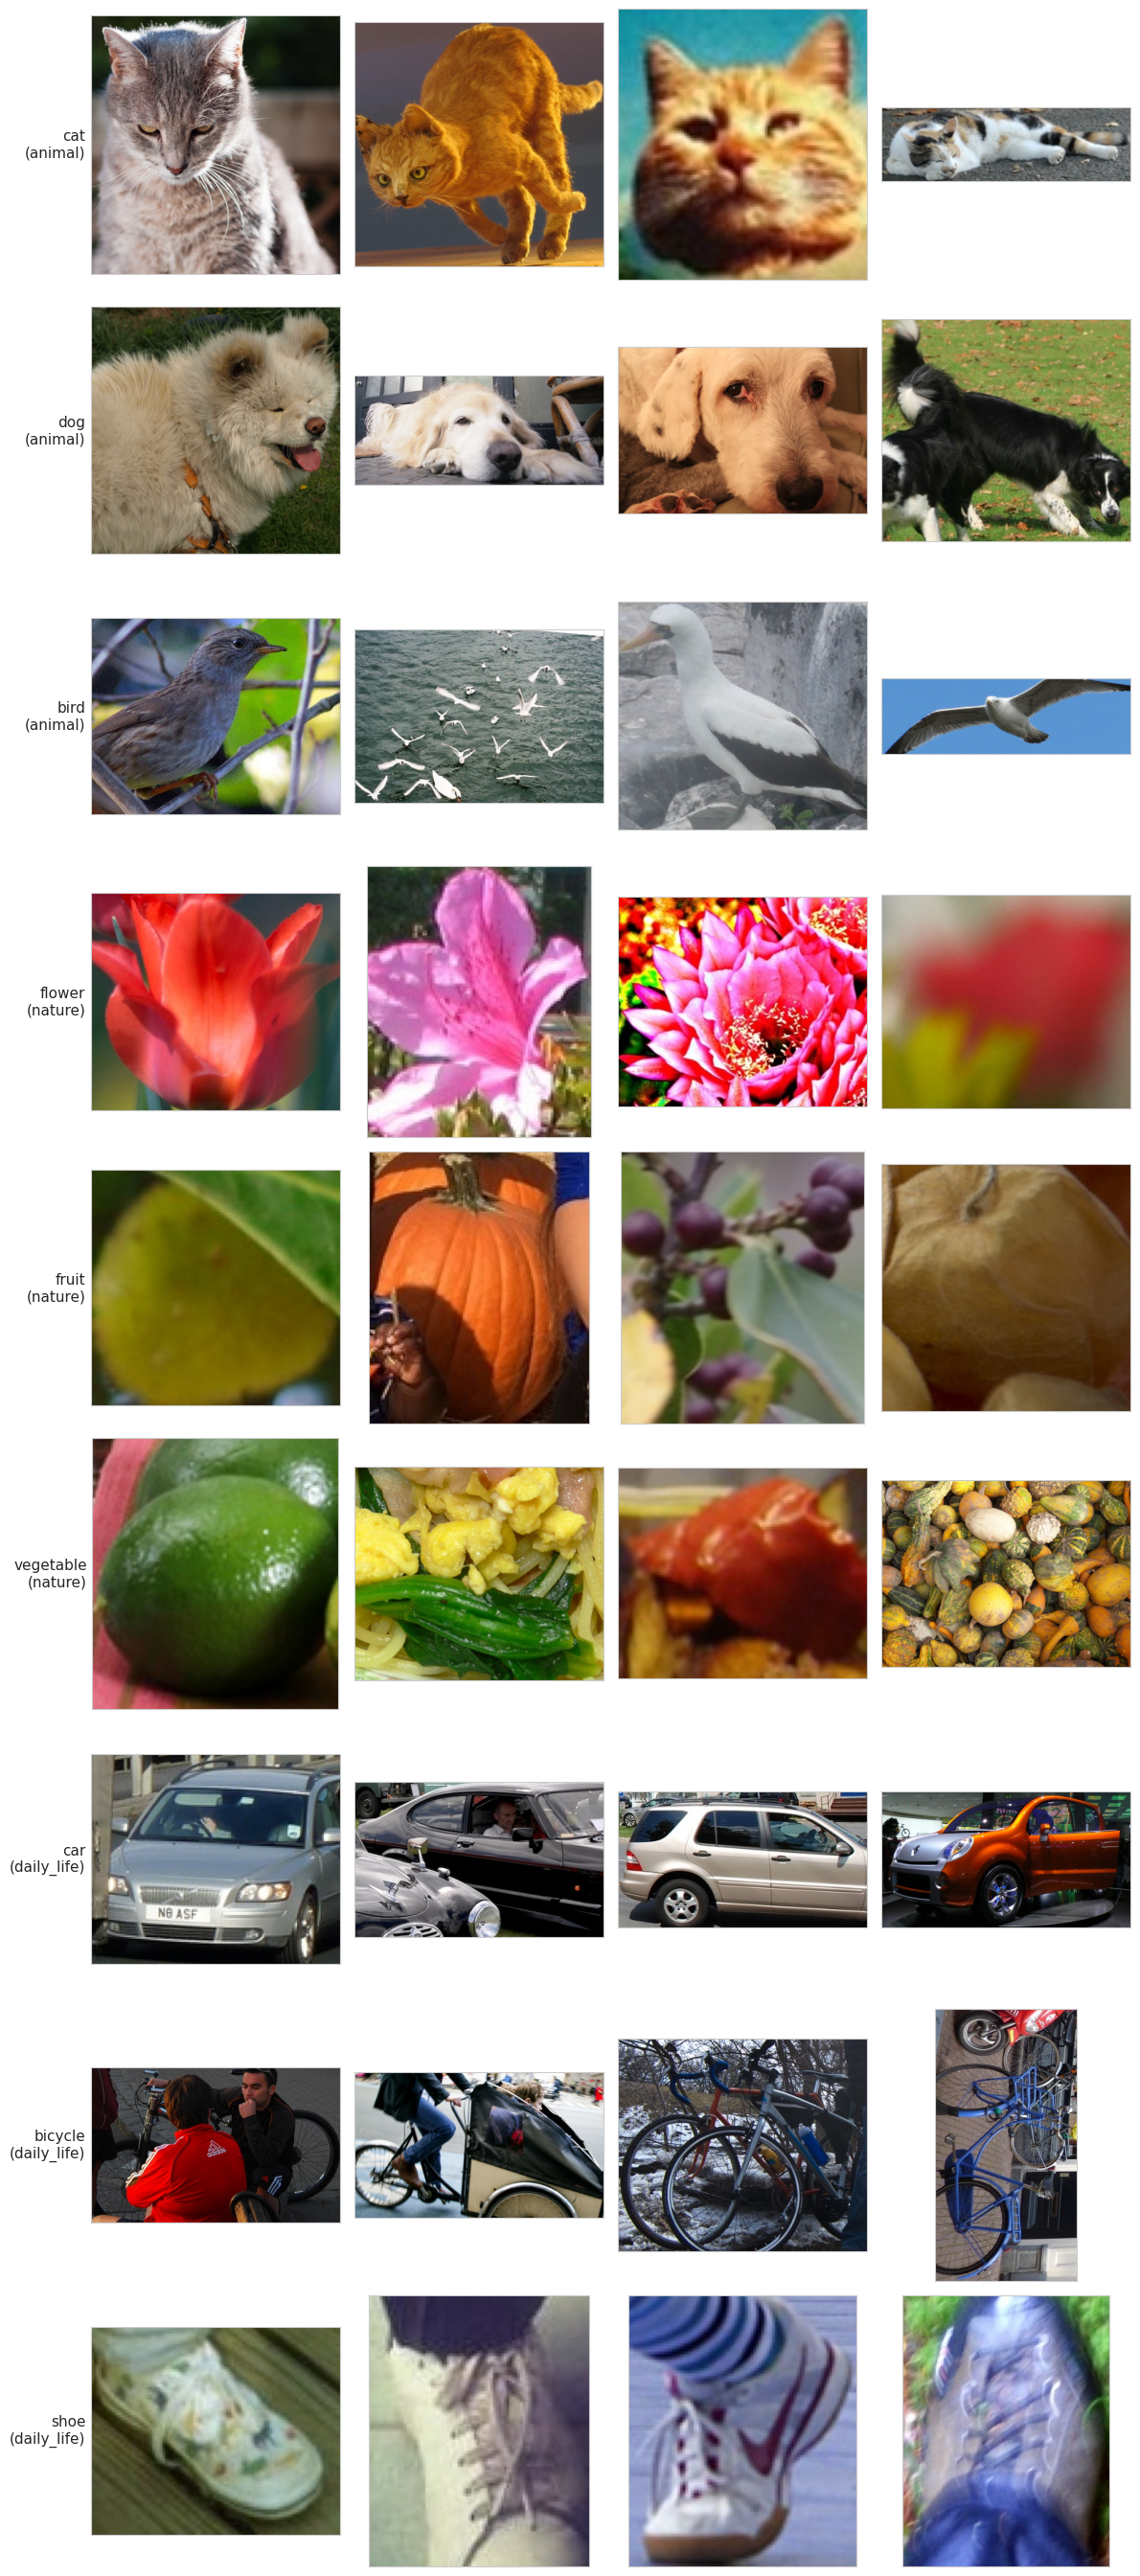

In [23]:
# Display 4 sample images per class
random.seed(42)
n_samples = 4
fig, axes = plt.subplots(9, n_samples, figsize=(n_samples * 3, 9 * 3))

# Display a few random sample images from each class
for row, cls in enumerate(CATEGORY_MAP.keys()):
    cls_files = df[df['class'] == cls]['path'].tolist()
    samples = random.sample(cls_files, min(n_samples, len(cls_files)))
    for col, path in enumerate(samples):
        ax = axes[row, col]
        ax.imshow(Image.open(path).convert('RGB'))

        # Show class and category label on the first image of each row
        if col == 0:
            ax.set_ylabel(f'{cls}\n({CATEGORY_MAP[cls]})',
                          fontsize=11, rotation=0, ha='right', va='center')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

## 8. Summary Report

In [26]:
print(f'Total images:      {len(df):,}')
print(f'Classes:           {df["class"].nunique()}')
print(f'Categories:        {df["category"].nunique()}')

print('\nSplit distribution:')
for split, n in df["split"].value_counts().items():
    print(f'  {split:6s}: {n:,} ({n / len(df) * 100:.1f}%)')

print('\nImage size:')
print(f'  Width:  median {df["width"].median():.0f}px '
      f'(min {df["width"].min()}, max {df["width"].max()})')
print(f'  Height: median {df["height"].median():.0f}px '
      f'(min {df["height"].min()}, max {df["height"].max()})')
print(f'  File:   median {df["file_kb"].median():.1f}KB')

Total images:      8,885
Classes:           9
Categories:        3

Split distribution:
  train : 6,219 (70.0%)
  val   : 1,333 (15.0%)
  test  : 1,333 (15.0%)

Image size:
  Width:  median 265px (min 80, max 1024)
  Height: median 235px (min 80, max 1024)
  File:   median 25.7KB
